# 🚢 **Titanic Dataset - Exploratory Data Analysis (EDA)**

This notebook demonstrates:

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Conclusion



### 1) Primary  Objective
- The objective of this exploratory data analysis is to investigate, clean, and analyze the Titanic passenger data to uncover key factors, trends, and demographic patterns that influenced passenger survival.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/competitions/titanic/data

- The data has been split into two groups:

  1-training set (train.csv)

  
  2-test set (test.csv)

  
  3-gender_submission(gender_submission.csv)


### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib and Seaborn Library.


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


### Import the CSV data into the Pandas Dataframe

In [6]:
# we will use train.csv for our analysis
df= pd.read_csv('train.csv')


### Display the First five Rows

In [8]:
# Preview  of data set 
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
# check the shape of data set
df.shape

(891, 12)

### 3. Key Feature Columns Summary

| Column Name | Category / Type | Description |
| :--- | :--- | :--- |
| **PassengerId** | Numerical | Unique ID per passenger |
| **Pclass** | Categorical | Ticket class (`1` = 1st, `2` = 2nd, `3` = 3rd) |
| **Name**, **Sex**, **Age** | Demographics | Passenger profile details |
| **SibSp** | Numerical | Number of siblings / spouses aboard |
| **Parch** | Numerical | Number of parents / children aboard |
| **Ticket**, **Fare**, **Cabin** | Logistics | Ticket ID, price paid, and cabin number |
| **Embarked** | Categorical | Port of Embarkation (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton) |

In [14]:
# DIfferentiate numerical and catagorical features
numerical_features=df.select_dtypes(exclude="object").columns.tolist
catagorical_features=df.select_dtypes(include="object").columns.tolist
print(f"Numerical features in the dataset are :{numerical_features}")
print(f"Catagorical  features in the dataset are :{catagorical_features}")

Numerical features in the dataset are :<bound method IndexOpsMixin.tolist of Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')>
Catagorical  features in the dataset are :<bound method IndexOpsMixin.tolist of Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')>


### 3- Data checks

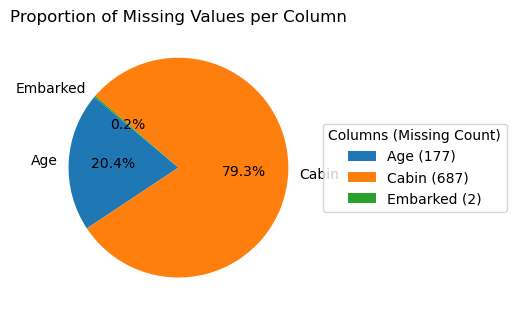

In [24]:
# Check missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

legend_labels = [f"{col} ({count})" for col, count in zip(missing_values.index, missing_values.values)]

# 3. Plot Pie Chart
plt.figure(figsize=(5,5))
ax = missing_values.plot(
    kind='pie',  
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Proportion of Missing Values per Column")
plt.ylabel("")

# Add legend with counts
plt.legend(legend_labels, title="Columns (Missing Count)", loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

In [ ]:
# s

In [ ]:
df["Cabin"].nunique(dropna=False)

148

In [ ]:
# Statistical summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Number of rows and columns
df.shape

(891, 12)

In [6]:
# Check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(exclude=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)


Categorical Columns:
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

Numerical Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')
